🏎️ Simulación y Predicción de Fórmula 1 con Machine Learning

📌 Descripción del proyecto

Este notebook 2 está centrado en la predicción de tiempos por vuelta en Fórmula 1 utilizando técnicas de Machine Learning (XGBoost) y simulación de carrera.

El objetivo es construir un modelo capaz de estimar el rendimiento de los pilotos en función de múltiples factores técnicos, históricos y contextuales, y posteriormente simular carreras completas vuelta a vuelta 🏁.

In [ ]:
import pandas as pd
import numpy as np
import exploracion as exp
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from xgboost import XGBRegressor
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-darkgrid')

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

📊 Datos utilizados

Se han combinado múltiples fuentes de datos de la temporada 2024:

  - 🏁 Resultados de carrera
  - ⏱️ Tiempos por vuelta (laps)
  - 👨‍✈️ Información de pilotos
  - 🏎️ Datos de equipos
  - 📅 Calendario de Grandes Premios

Además, se han añadido variables externas como:

  - 🧠 Historial de rendimiento de pilotos y equipos
  - 🪶 Carga aerodinámica por circuito y equipo
  - 🔥 Degradación de neumáticos
  - ⛽ Variables de stint y experiencia en carrera

RESULTADOS 2024
Numero de registros:
479
Numero de columnas:
25
Tipos de Datos:
DriverNumber            int64
BroadcastName          object
Abbreviation           object
DriverId               object
TeamName               object
TeamColor              object
TeamId                 object
FirstName              object
LastName               object
FullName               object
HeadshotUrl            object
CountryCode            object
Position              float64
ClassifiedPosition     object
GridPosition          float64
Q1                    float64
Q2                    float64
Q3                    float64
Time                   object
Status                 object
Points                float64
Laps                  float64
Season                  int64
GrandPrix              object
Session                object
dtype: object
Información:
<class 'pandas.core.frame.DataFrame'>
Index: 479 entries, 0 to 139
Data columns (total 25 columns):
 #   Column              Non-Null Count  Dt

/content/exploracion.py:56: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


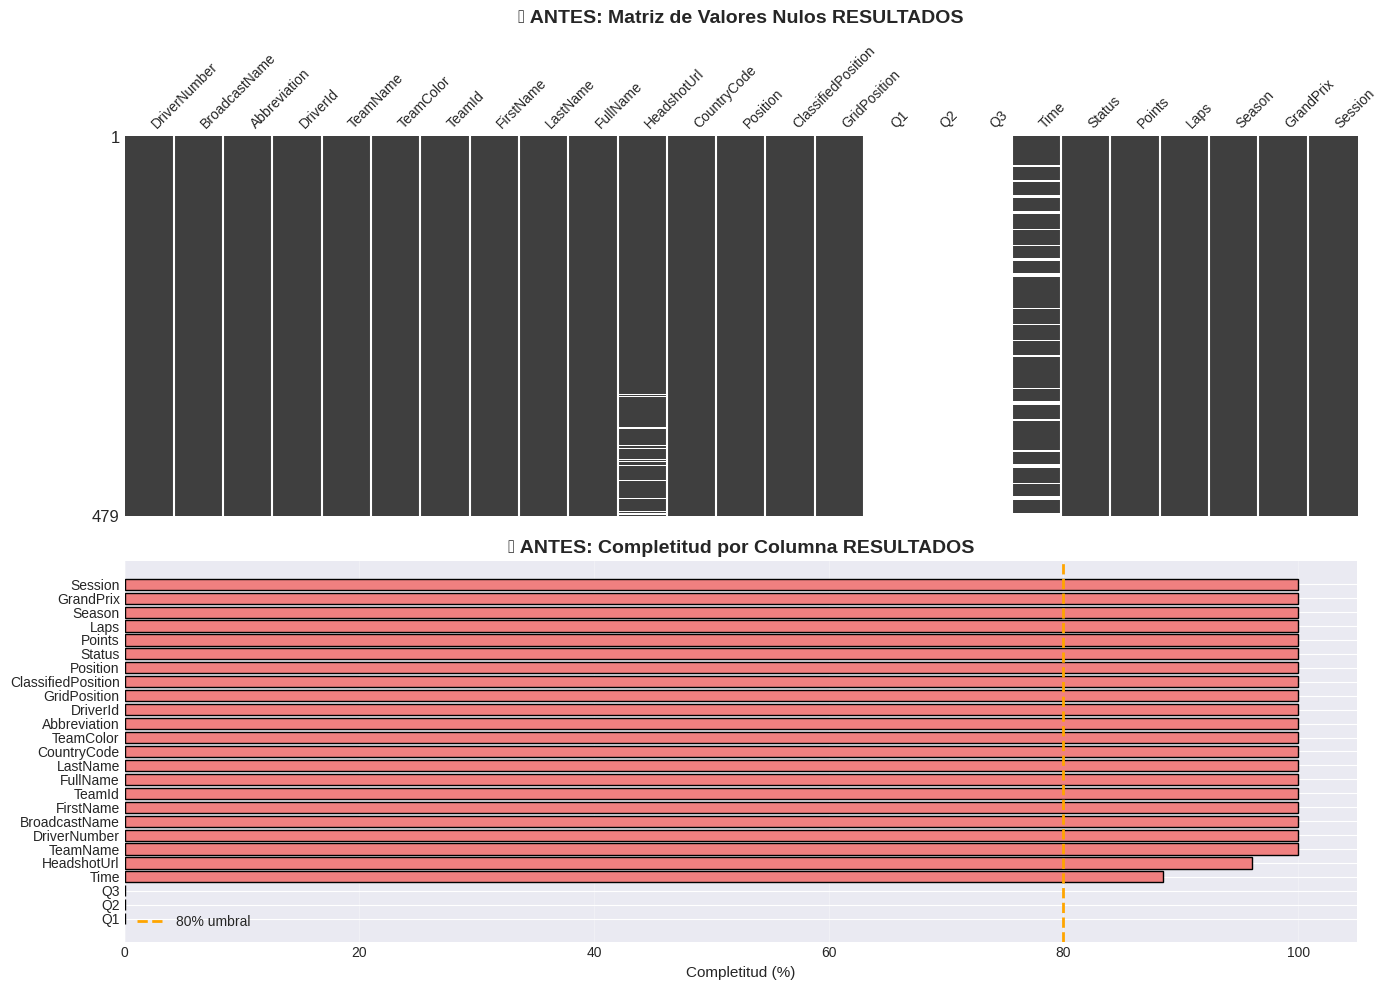


⚠️  Columnas con más del 20% de datos faltantes:
   - Q1: 479 nulos (100.0%)
   - Q2: 479 nulos (100.0%)
   - Q3: 479 nulos (100.0%)
VUELTAS 2024
Numero de registros:
24604
Numero de columnas:
33
Tipos de Datos:
GrandPrix              object
Season                  int64
Time                   object
Driver                 object
DriverNumber            int64
LapTime                object
LapNumber             float64
Stint                 float64
PitOutTime             object
PitInTime              object
Sector1Time            object
Sector2Time            object
Sector3Time            object
Sector1SessionTime     object
Sector2SessionTime     object
Sector3SessionTime     object
SpeedI1               float64
SpeedI2               float64
SpeedFL               float64
SpeedST               float64
IsPersonalBest         object
Compound               object
TyreLife              float64
FreshTyre                bool
Team                   object
LapStartTime           object
LapStar

/content/exploracion.py:56: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


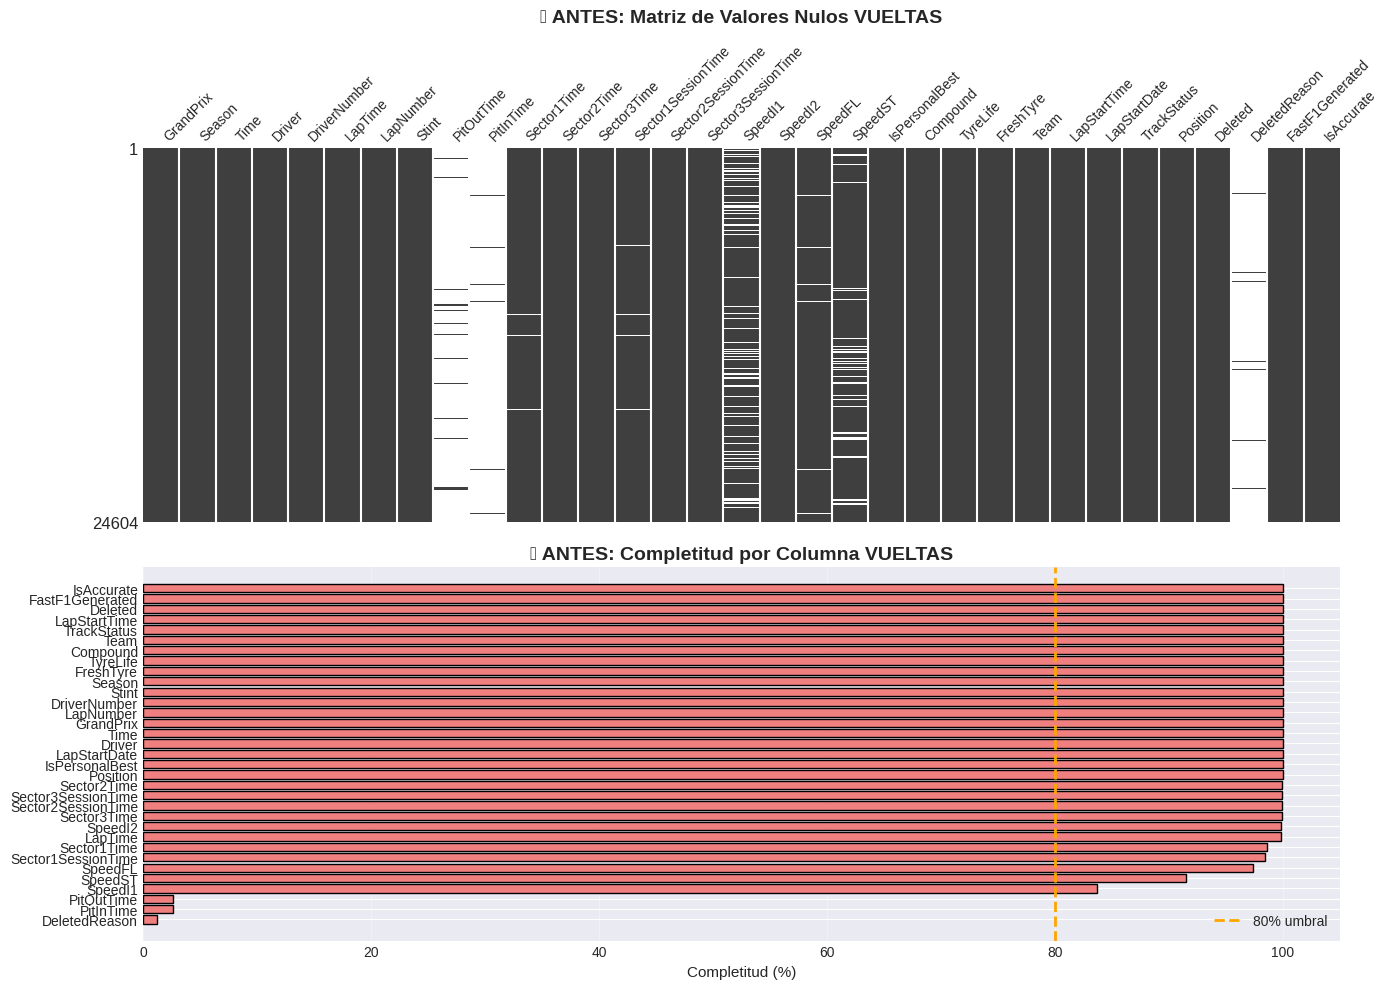


⚠️  Columnas con más del 20% de datos faltantes:
   - PitOutTime: 23955 nulos (97.4%)
   - PitInTime: 23962 nulos (97.4%)
   - DeletedReason: 24307 nulos (98.8%)
PILOTOS 2024
Numero de registros:
45
Numero de columnas:
22
Tipos de Datos:
DriverNumber            int64
BroadcastName          object
Abbreviation           object
DriverId               object
TeamName               object
TeamColor              object
TeamId                 object
FirstName              object
LastName               object
FullName               object
HeadshotUrl            object
CountryCode            object
Position              float64
ClassifiedPosition     object
GridPosition          float64
Q1                    float64
Q2                    float64
Q3                    float64
Time                   object
Status                 object
Points                float64
Laps                  float64
dtype: object
Información:
<class 'pandas.core.frame.DataFrame'>
Index: 45 entries, 0 to 22
Data colu

/content/exploracion.py:56: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


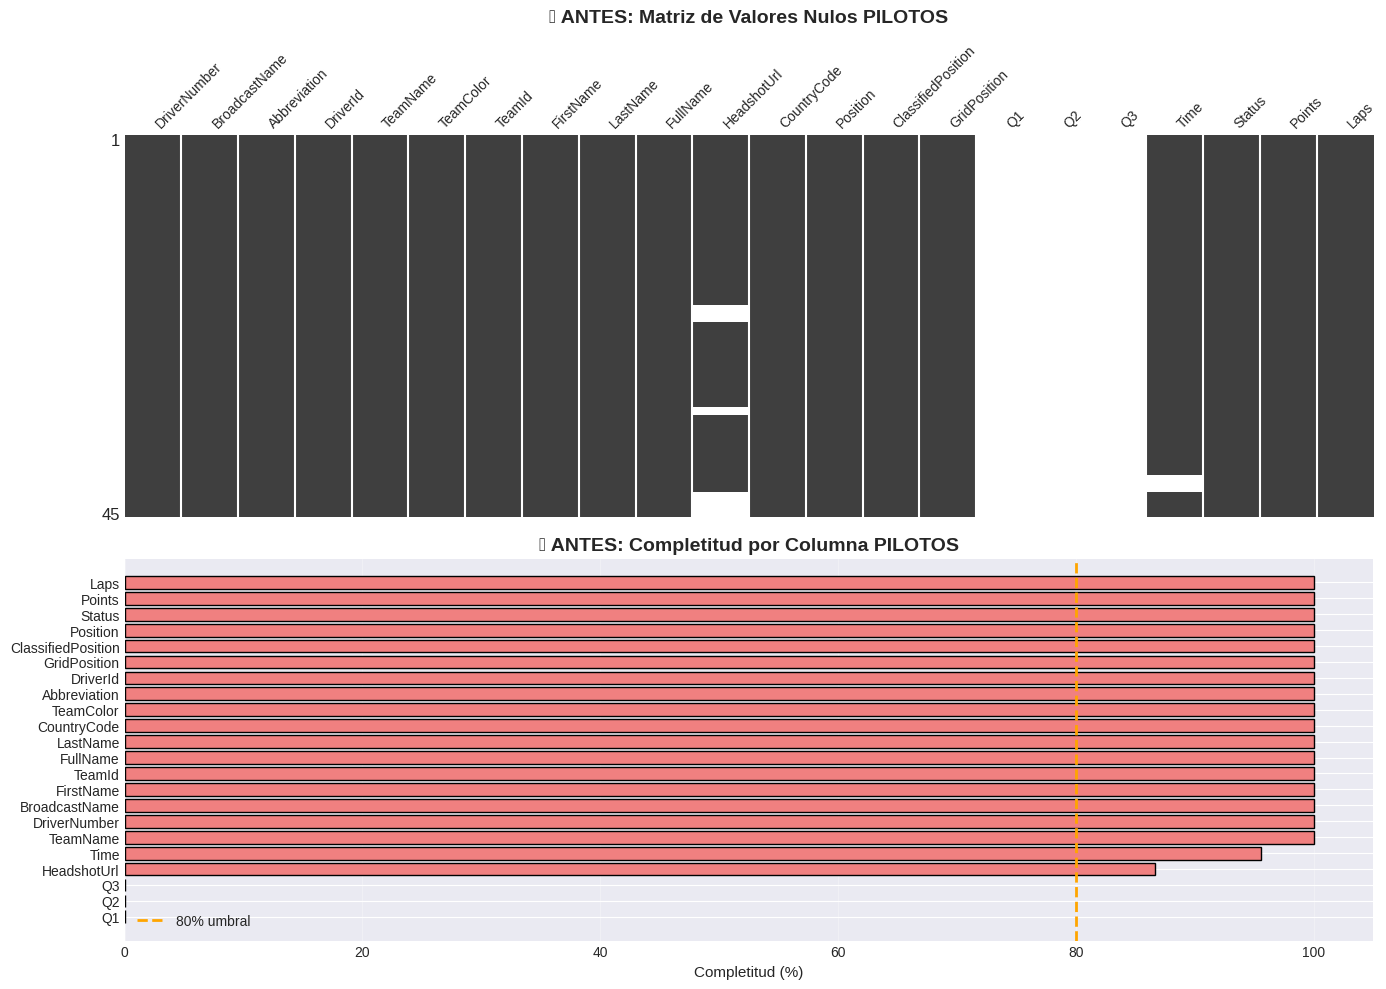


⚠️  Columnas con más del 20% de datos faltantes:
   - Q1: 45 nulos (100.0%)
   - Q2: 45 nulos (100.0%)
   - Q3: 45 nulos (100.0%)
EQUIPOS 2024
Numero de registros:
11
Numero de columnas:
3
Tipos de Datos:
TeamName     object
TeamColor    object
TeamId       object
dtype: object
Información:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11 entries, 0 to 10
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   TeamName   11 non-null     object
 1   TeamColor  11 non-null     object
 2   TeamId     11 non-null     object
dtypes: object(3)
memory usage: 396.0+ bytes
None

Primeras filas:
       TeamName TeamColor        TeamId
0        Alpine    ff87bc        alpine
1  Aston Martin    229971  aston_martin
2       Ferrari    e8002d       ferrari
3  Haas F1 Team    b6babd          haas
4   Kick Sauber    52e252        sauber

Estadísticas descriptivas:
        TeamName TeamColor    TeamId
count         11        11        11
u

/content/exploracion.py:56: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


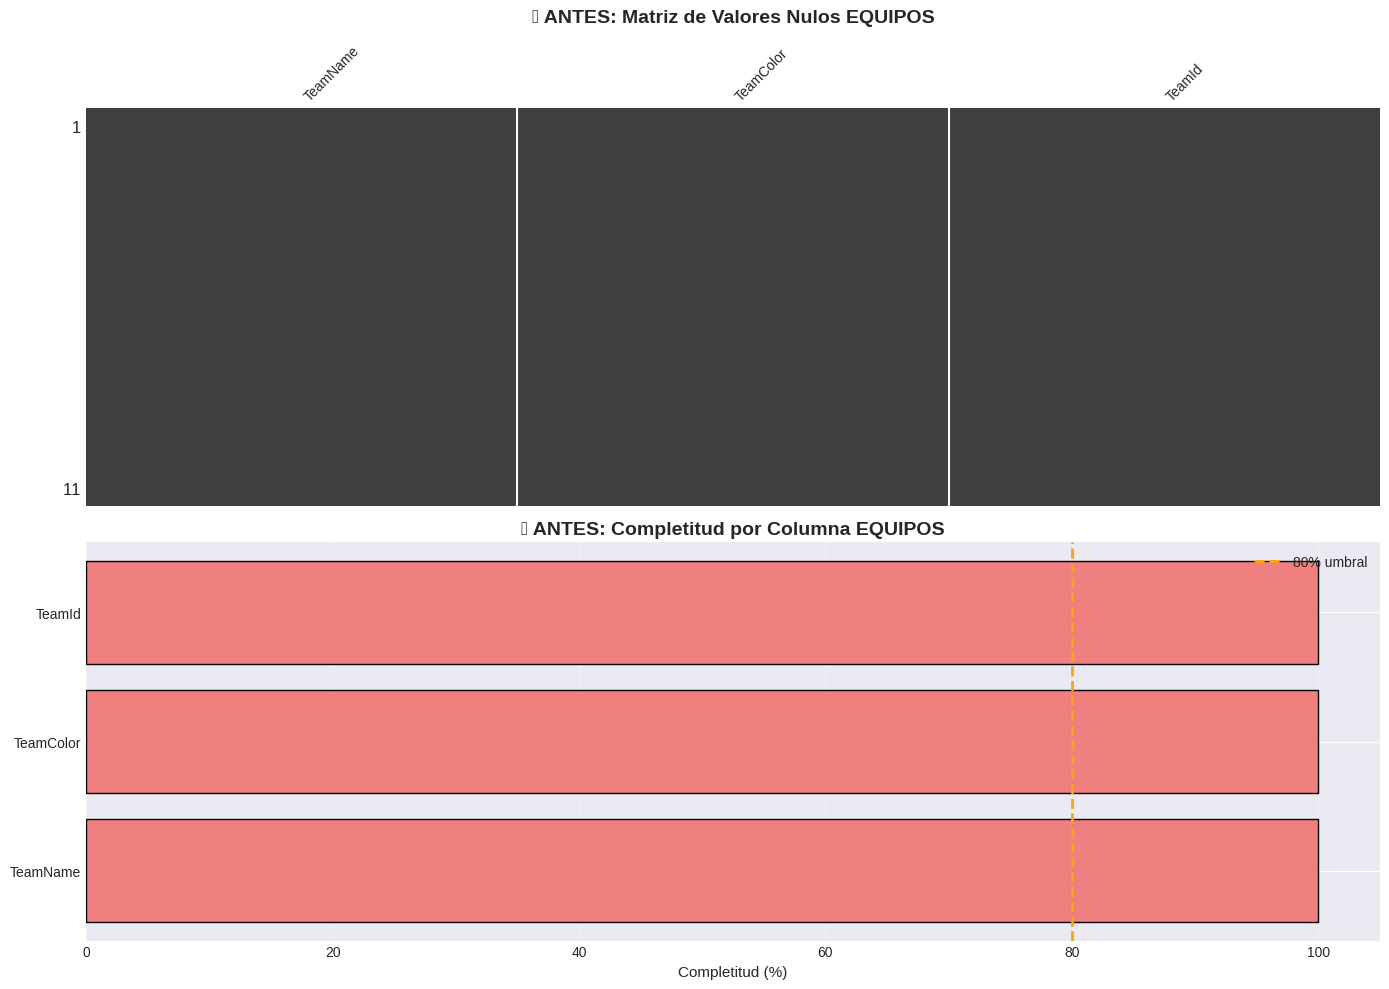


⚠️  Columnas con más del 20% de datos faltantes:
CALENDARIO 2024
Numero de registros:
25
Numero de columnas:
23
Tipos de Datos:
RoundNumber           int64
Country              object
Location             object
OfficialEventName    object
EventDate            object
EventName            object
EventFormat          object
Session1             object
Session1Date         object
Session1DateUtc      object
Session2             object
Session2Date         object
Session2DateUtc      object
Session3             object
Session3Date         object
Session3DateUtc      object
Session4             object
Session4Date         object
Session4DateUtc      object
Session5             object
Session5Date         object
Session5DateUtc      object
F1ApiSupport           bool
dtype: object
Información:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 23 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0 

/content/exploracion.py:56: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


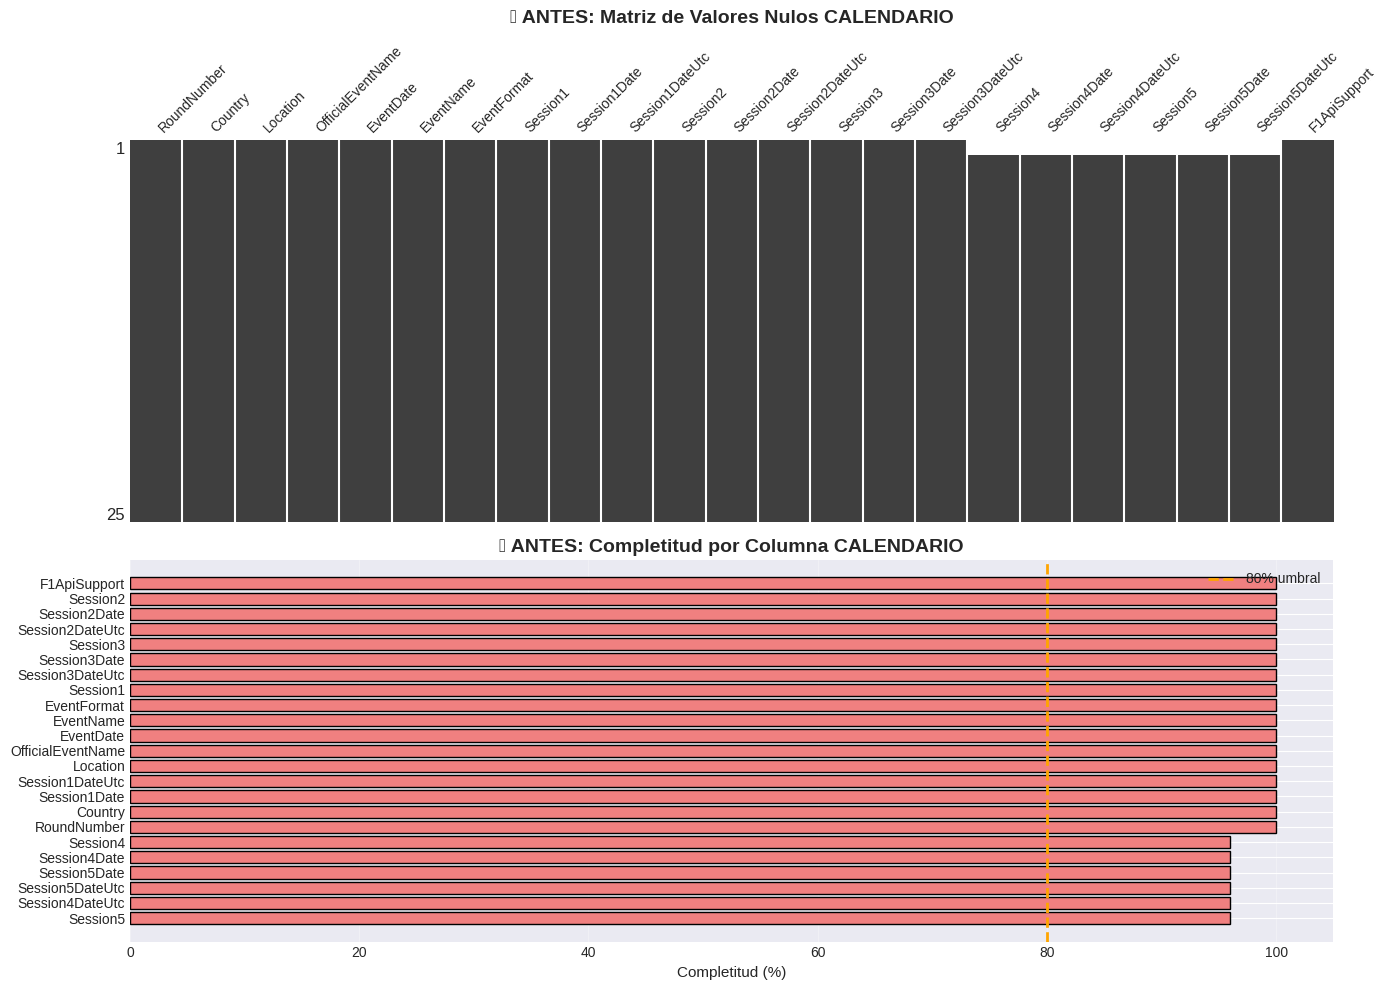


⚠️  Columnas con más del 20% de datos faltantes:


In [ ]:
# ─────────────────────────────────────────────
# LECTURA DATAFRAMES
# ─────────────────────────────────────────────

df_resultados_2024_1 = pd.read_csv('resultados_2024_1.csv')
df_resultados_2024_2 = pd.read_csv('resultados_2024_2.csv')
df_resultados = pd.concat([df_resultados_2024_1, df_resultados_2024_2])

df_laps_2024_1 = pd.read_csv('laps_2024_1.csv')
df_laps_2024_2 = pd.read_csv('laps_2024_2.csv')

df_laps_all = pd.concat([df_laps_2024_1, df_laps_2024_2])
df_laps     = df_laps_all[df_laps_all['TrackStatus'] == 1].copy()

df_pilotos_2024_1 = pd.read_csv('pilotos_2024_1.csv')
df_pilotos_2024_2 = pd.read_csv('pilotos_2024_2.csv')
df_pilotos = pd.concat([df_pilotos_2024_1, df_pilotos_2024_2])

df_equipos    = pd.read_csv('equipos_2024_1.csv')
df_calendario = pd.read_csv('schedule_2024.csv')

# ─────────────────────────────────────────────
# EXPLORACIÓN BÁSICA
# ─────────────────────────────────────────────

dataframes = {
    "RESULTADOS": df_resultados,
    "VUELTAS":    df_laps,
    "PILOTOS":    df_pilotos,
    "EQUIPOS":    df_equipos,
    "CALENDARIO": df_calendario
}

for nombre, df in dataframes.items():
    exp.explorar_df(df, nombre)
    exp.valores_nulos(df, nombre)
    exp.filas_vacias(df)
    exp.duplicados(df)
    exp.visualizacion_outliers(df, nombre)

# ─────────────────────────────────────────────
# PREPROCESADO DE TIEMPOS
# ─────────────────────────────────────────────

cols_time = ['LapTime', 'Sector1Time', 'Sector2Time', 'Sector3Time']
for col in cols_time:
    df_laps[col] = pd.to_timedelta(df_laps[col], errors='coerce').dt.total_seconds()

df_laps['LapStartDate'] = pd.to_datetime(df_laps['LapStartDate'], errors='coerce')

cols_drop = [
    'Time', 'PitOutTime', 'PitInTime',
    'Sector1SessionTime', 'Sector2SessionTime', 'Sector3SessionTime',
    'LapStartTime', 'LapStartDate',
    'FastF1Generated', 'Deleted', 'DeletedReason'
]
df_laps = df_laps.drop(columns=cols_drop)
df_laps = df_laps.dropna(subset=['LapTime'])

🧠 Ingeniería de variables (Feature Engineering)

Se han creado variables avanzadas para mejorar la capacidad predictiva del modelo:

  - 📈 Pace histórico de pilotos y equipos
  - 🔁 Media móvil de rendimiento
  - 🎯 Consistencia de piloto (desviación estándar de tiempos)
  - 🧩 Eficiencia aerodinámica combinada
  - 🛞 Degradación de neumáticos por stint
  - 🧑‍🏫 Penalizaciones por rookies y cambios de equipo

In [ ]:

# ─────────────────────────────────────────────
# FEATURES EXTERNAS: AERODINÁMICA
# ─────────────────────────────────────────────

df_fia_circuit = pd.DataFrame({
    'GrandPrix': [
        'Bahrain Grand Prix', 'Saudi Arabian Grand Prix', 'Australian Grand Prix',
        'Japanese Grand Prix', 'Chinese Grand Prix', 'Miami Grand Prix',
        'Emilia Romagna Grand Prix', 'Monaco Grand Prix', 'Canadian Grand Prix',
        'Spanish Grand Prix', 'Austrian Grand Prix', 'British Grand Prix',
        'Hungarian Grand Prix', 'Belgian Grand Prix', 'Dutch Grand Prix',
        'Italian Grand Prix', 'Azerbaijan Grand Prix', 'Singapore Grand Prix',
        'United States Grand Prix', 'Mexico City Grand Prix', 'São Paulo Grand Prix',
        'Las Vegas Grand Prix', 'Qatar Grand Prix', 'Abu Dhabi Grand Prix'
    ],
    'carga_aerodinamica_circuito': [
        0.30, 0.25, 0.30, 0.85, 0.90, 0.70, 0.80, 1.00, 0.30, 0.85,
        0.20, 0.80, 0.95, 0.75, 0.60, 0.10, 0.15, 0.95, 0.70, 0.25,
        0.30, 0.20, 0.25, 0.30
    ]
})

df_fia_aero = pd.DataFrame({
    'Team': [
        'Red Bull Racing', 'Mercedes', 'Ferrari', 'McLaren', 'Aston Martin',
        'Alpine', 'RB', 'Williams', 'Haas F1 Team', 'Kick Sauber'
    ],
    'carga_aerodinamica_equipo': [
        0.90, 0.85, 0.82, 0.80, 0.70, 0.65, 0.60, 0.55, 0.50, 0.50
    ]
})

df_laps['Team']             = df_laps['Team'].str.strip()
df_laps['GrandPrix']        = df_laps['GrandPrix'].str.strip()
df_fia_aero['Team']         = df_fia_aero['Team'].str.strip()
df_fia_circuit['GrandPrix'] = df_fia_circuit['GrandPrix'].str.strip()

df_laps = df_laps.merge(df_fia_aero,    on='Team',     how='left')
df_laps = df_laps.merge(df_fia_circuit, on='GrandPrix', how='left')

df_laps['aero_efficiency'] = (
    df_laps['carga_aerodinamica_equipo'] *
    df_laps['carga_aerodinamica_circuito']
)
df_laps['circuit_type'] = df_laps['carga_aerodinamica_circuito'].apply(
    lambda x: 'high' if x > 0.8 else ('medium' if x > 0.4 else 'low')
)
df_laps['driver_hist_pace'] = df_laps.groupby('Driver')['LapTime'].transform(
    lambda x: x.shift(1).expanding().mean()
)
df_laps['driver_rolling_pace'] = df_laps.groupby('Driver')['LapTime'].transform(
    lambda x: x.shift(1).rolling(3, min_periods=1).mean()
)
df_laps['driver_hist_consistency'] = df_laps.groupby('Driver')['LapTime'].transform(
    lambda x: x.shift(1).expanding().std()
)
df_laps['team_hist_pace'] = df_laps.groupby('Team')['LapTime'].transform(
    lambda x: x.shift(1).expanding().mean()
)

df_laps['driver_hist_pace']        = df_laps['driver_hist_pace'].fillna(df_laps.groupby('Driver')['LapTime'].transform('mean'))
df_laps['driver_rolling_pace']     = df_laps['driver_rolling_pace'].fillna(df_laps.groupby('Driver')['LapTime'].transform('mean'))
df_laps['driver_hist_consistency'] = df_laps['driver_hist_consistency'].fillna(df_laps.groupby('Driver')['LapTime'].transform('std'))
df_laps['team_hist_pace']          = df_laps['team_hist_pace'].fillna(df_laps.groupby('Team')['LapTime'].transform('mean'))

df_laps['car_performance'] = (
    df_laps['carga_aerodinamica_equipo'] * 0.7 +
    df_laps['carga_aerodinamica_circuito'] * 0.3
)
df_laps['base_car_time'] = (1 - df_laps['carga_aerodinamica_equipo']) * 2.0
df_laps['car_penalty']   = (1 - df_laps['car_performance']) * 2.5

df_laps['stint_age']       = df_laps.groupby(['GrandPrix', 'Driver', 'Stint']).cumcount() + 1
df_laps['tyre_degradation'] = np.log1p(df_laps['stint_age']) * df_laps['carga_aerodinamica_circuito']
df_laps['race_number']      = df_laps.groupby('Driver').cumcount() + 1


🤖 Modelo de Machine Learning

Se utiliza un modelo XGBoost Regressor, entrenado para predecir:

⏱️ Tiempo de vuelta (LapTime)

📌 Configuración:
  - 500 árboles
  - Profundidad máxima: 6
  - Learning rate: 0.05

📉 Métrica principal:

  - MAE (Mean Absolute Error) en segundos

In [ ]:
# ─────────────────────────────────────────────
# MODELO
# ─────────────────────────────────────────────

FEATURES_NUMERICAS = [
    'car_performance', 'car_penalty',
    'carga_aerodinamica_equipo', 'carga_aerodinamica_circuito', 'aero_efficiency',
    'SpeedST', 'TyreLife', 'LapNumber',
    'tyre_degradation', 'stint_age',
    'race_number',
    'driver_hist_pace', 'driver_rolling_pace', 'driver_hist_consistency',
    'team_hist_pace',
]
FEATURES_CATEGORICAS = ['Driver', 'Team', 'GrandPrix', 'circuit_type']

df_model_base = df_laps[FEATURES_NUMERICAS + FEATURES_CATEGORICAS + ['LapTime']].copy()
df_model_base = df_model_base.dropna()
df_model      = pd.get_dummies(df_model_base, columns=FEATURES_CATEGORICAS)

obj_cols = df_model.select_dtypes(include='object').columns.tolist()
if obj_cols:
    df_model = df_model.drop(columns=obj_cols)

X = df_model.drop(columns=['LapTime'])
y = df_model['LapTime']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = XGBRegressor(n_estimators=500, max_depth=6, learning_rate=0.05, random_state=42)
model.fit(X_train, y_train)

pred_test = model.predict(X_test)
mae       = mean_absolute_error(y_test, pred_test)
print(f"MAE en test: {mae:.4f} segundos")

feat_imp = pd.Series(model.feature_importances_, index=X.columns)
print("\nTop 15 features más importantes:")
print(feat_imp.sort_values(ascending=False).head(15))

MAE en test: 0.7946 segundos

Top 15 features más importantes:
driver_rolling_pace                    0.271116
GrandPrix_Austrian Grand Prix          0.205825
stint_age                              0.076623
GrandPrix_Dutch Grand Prix             0.046218
GrandPrix_Belgian Grand Prix           0.034314
circuit_type_medium                    0.029717
GrandPrix_Azerbaijan Grand Prix        0.028704
GrandPrix_Abu Dhabi Grand Prix         0.026889
GrandPrix_Japanese Grand Prix          0.026722
GrandPrix_Mexico City Grand Prix       0.026168
carga_aerodinamica_circuito            0.022982
GrandPrix_Emilia Romagna Grand Prix    0.020380
TyreLife                               0.016453
GrandPrix_Australian Grand Prix        0.013245
GrandPrix_Las Vegas Grand Prix         0.013080
dtype: float32


🏁 Simulación de carrera

El modelo se utiliza para simular carreras completas:

  - Simulación vuelta a vuelta
  - Evolución de posiciones 📊
  - Variabilidad aleatoria (ruido realista)
  - Penalizaciones por adaptación (rookies / cambios de equipo)

In [ ]:
# ─────────────────────────────────────────────
# CONFIGURACIÓN PARRILLA 2025
# ─────────────────────────────────────────────

driver_team_2025 = {
    'SAI': 'Williams',      'HAM': 'Ferrari',
    'RUS': 'Mercedes',      'ANT': 'Mercedes',
    'LEC': 'Ferrari',       'NOR': 'McLaren',
    'PIA': 'McLaren',       'VER': 'Red Bull Racing',
    'LAW': 'Red Bull Racing','ALO': 'Aston Martin',
    'STR': 'Aston Martin',  'GAS': 'Alpine',
    'DOO': 'Alpine',        'ALB': 'Williams',
    'TSU': 'RB',            'HAD': 'RB',
    'BEA': 'Haas F1 Team',  'OCO': 'Haas F1 Team',
    'BOT': 'Kick Sauber',   'HUL': 'Kick Sauber',
}

team_colors = {
    'Red Bull Racing': '#3671C6', 'Mercedes':     '#27F4D2',
    'Ferrari':         '#E8002D', 'McLaren':      '#FF8000',
    'Aston Martin':    '#229971', 'Alpine':       '#FF87BC',
    'RB':              '#6692FF', 'Williams':     '#64C4FF',
    'Haas F1 Team':    '#B6BABD', 'Kick Sauber':  '#52E252',
}
driver_color_map = {d: team_colors.get(t, '#888888') for d, t in driver_team_2025.items()}

rookies      = {'ANT', 'HAD', 'DOO', 'BEA'}
team_changes = {'SAI', 'HAM', 'LAW', 'HUL', 'OCO'}

PENALTY_ROOKIE      = 1.5
PENALTY_TEAM_CHANGE = 0.6
DECAY_RACES         = 8

def adaptation_penalty(driver, race_number):
    if driver in rookies:
        base = PENALTY_ROOKIE
    elif driver in team_changes:
        base = PENALTY_TEAM_CHANGE
    else:
        return 0.0
    decay = DECAY_RACES / np.log(20)
    return base * np.exp(-race_number / decay)

# ─────────────────────────────────────────────
# SIMULACIÓN GP VUELTA A VUELTA
# ─────────────────────────────────────────────

def simular_gp(gp_name, n_laps, driver_team, race_number_map=None, noise_std=0.15):

    if race_number_map is None:
        race_number_map = {d: 1 for d in driver_team}

    drivers   = list(driver_team.keys())
    gp_info   = df_fia_circuit[df_fia_circuit['GrandPrix'] == gp_name].iloc[0]
    team_info = df_fia_aero.set_index('Team')

    circuit_aero = gp_info['carga_aerodinamica_circuito']
    circuit_type = 'high' if circuit_aero > 0.8 else ('medium' if circuit_aero > 0.4 else 'low')

    gp_speed_mean = df_laps[df_laps['GrandPrix'] == gp_name]['SpeedST'].mean()
    gp_tyrelife_mean = df_laps[df_laps['GrandPrix'] == gp_name]['TyreLife'].mean()

    driver_state = {
        d: {'rolling': [], 'stint_age': 0}
        for d in drivers
    }

    cumulative_time = {d: 0.0 for d in drivers}
    history_positions = {d: [] for d in drivers}
    history_laptimes = {d: [] for d in drivers}

    np.random.seed(None)

    # ─────────────────────────────────────────────
    # LOOP DE CARRERA
    # ─────────────────────────────────────────────
    for lap in range(1, n_laps + 1):

        rows = []

        for d in drivers:
            team = driver_team[d]

            driver_state[d]['stint_age'] += 1
            stint_age = driver_state[d]['stint_age']

            tyre_deg = np.log1p(stint_age) * circuit_aero

            team_aero = team_info.loc[team, 'carga_aerodinamica_equipo'] if team in team_info.index else 0.6

            car_perf = team_aero * 0.7 + circuit_aero * 0.3
            car_penalty = (1 - car_perf) * 2.5
            aero_eff = team_aero * circuit_aero

            rolling = driver_state[d]['rolling']
            hist_mean = np.mean(rolling) if rolling else df_laps['LapTime'].mean()
            hist_std  = np.std(rolling) if len(rolling) > 1 else 0.3

            team_hist = df_laps[df_laps['Team'] == team]['LapTime'].mean()

            rows.append({
                'Driver': d,
                'Team': team,
                'GrandPrix': gp_name,
                'circuit_type': circuit_type,
                'LapNumber': lap,
                'race_number': race_number_map.get(d, 1),

                'carga_aerodinamica_equipo': team_aero,
                'carga_aerodinamica_circuito': circuit_aero,
                'aero_efficiency': aero_eff,

                'car_performance': car_perf,
                'car_penalty': car_penalty,

                'SpeedST': gp_speed_mean,
                'TyreLife': gp_tyrelife_mean,

                'stint_age': stint_age,
                'tyre_degradation': tyre_deg,

                'driver_hist_pace': hist_mean,
                'driver_rolling_pace': hist_mean,
                'driver_hist_consistency': hist_std,
                'team_hist_pace': team_hist,
            })

        lap_df = pd.DataFrame(rows)

        # ─────────────────────────────
        # PREPARAR INPUT MODELO
        # ─────────────────────────────
        X_lap = pd.get_dummies(lap_df, columns=['Driver', 'Team', 'GrandPrix', 'circuit_type'])

        for col in X_train.columns:
            if col not in X_lap.columns:
                X_lap[col] = 0

        X_lap = X_lap[X_train.columns]

        # ─────────────────────────────
        # PREDICCIÓN
        # ─────────────────────────────
        pred_times = model.predict(X_lap)

        noise = np.random.normal(0, noise_std, len(drivers))
        adapt_pen = np.array([
            adaptation_penalty(d, race_number_map.get(d, 1))
            for d in drivers
        ])

        final_times = pred_times + noise + adapt_pen

        # ─────────────────────────────
        # ACTUALIZAR ESTADO
        # ─────────────────────────────
        for i, d in enumerate(drivers):
            lt = final_times[i]

            cumulative_time[d] += lt
            history_laptimes[d].append(lt)

            driver_state[d]['rolling'].append(lt)
            if len(driver_state[d]['rolling']) > 5:
                driver_state[d]['rolling'].pop(0)

        # posiciones
        sorted_drivers = sorted(cumulative_time.items(), key=lambda x: x[1])

        for pos, (d, _) in enumerate(sorted_drivers, 1):
            history_positions[d].append(pos)

    # ─────────────────────────────────────────────
    # RESULTADO FINAL
    # ─────────────────────────────────────────────
    final_result = pd.DataFrame([
        {'Driver': d, 'Team': driver_team[d], 'TotalTime': cumulative_time[d]}
        for d in drivers
    ]).sort_values('TotalTime').reset_index(drop=True)

    final_result['Position'] = range(1, len(drivers) + 1)

    return history_positions, history_laptimes, final_result

📈 Visualizaciones generadas

El notebook incluye gráficos para analizar:

  - 📍 Evolución de posiciones por vuelta
  - ⏱️ Tiempos de vuelta por piloto
  - ⚔️ Comparativas entre pilotos (ej: Alonso vs Stroll)
  - 🧾 Resultado final de carrera simulada

In [ ]:
def plot_gp_positions(history_positions, n_laps, gp_name, driver_team):
    """Gráfico de evolución de posiciones vuelta a vuelta."""

    fig, ax = plt.subplots(figsize=(18, 9))

    for d, positions in history_positions.items():
        color     = driver_color_map.get(d, '#888888')
        linestyle = '--' if d in (rookies | team_changes) else '-'

        ax.plot(
            range(1, n_laps + 1), positions,
            color=color, linewidth=2,
            linestyle=linestyle, alpha=0.85
        )
        ax.text(
            n_laps + 0.5,
            positions[-1],
            d,
            fontsize=9,
            fontweight='bold',
            color='white',
            va='center',
            bbox=dict(
                boxstyle="round,pad=0.35",  # 👈 borde redondeado
                facecolor=color,
                edgecolor='black',
                linewidth=0.8,
                alpha=0.95
            )
        )

    ax.invert_yaxis()
    ax.set_xlim(1, n_laps + 5)
    ax.set_yticks(range(1, len(history_positions) + 1))
    ax.set_xlabel('Lap', fontsize=12)
    ax.set_ylabel('Position', fontsize=12)
    ax.set_title(
        f'Lap-by-Lap Positions — {gp_name} 2025 (Simulated)'
        ,
        fontsize=13, fontweight='bold'
    )
    ax.grid(alpha=0.25)

    # Leyenda de equipos
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], color=team_colors[t], linewidth=3, label=t)
        for t in team_colors
    ]
    ax.legend(handles=legend_elements, bbox_to_anchor=(1.01, 1),
              loc='upper left', fontsize=8, frameon=False)

    plt.tight_layout()
    fname = gp_name.replace(' ', '_') + '_positions_2025.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Gráfico guardado: {fname}")

🧪 Caso de estudio

Ejemplo aplicado:
🏁 Gran Premio de Bahréin (simulación 2025)

Se simula toda la carrera con la parrilla actualizada, obteniendo:

  - Clasificación final
  - Evolución de carrera
  - Rendimiento individual por piloto


  SIMULANDO: Bahrain Grand Prix (57 vueltas)

=== RESULTADO FINAL — Bahrain Grand Prix 2025 (Simulado) ===
 Position Driver            Team
        1    VER Red Bull Racing
        2    LEC         Ferrari
        3    STR    Aston Martin
        4    ALO    Aston Martin
        5    ALB        Williams
        6    HAM         Ferrari
        7    BOT     Kick Sauber
        8    SAI        Williams
        9    PIA         McLaren
       10    NOR         McLaren
       11    GAS          Alpine
       12    RUS        Mercedes
       13    TSU              RB
       14    LAW Red Bull Racing
       15    OCO    Haas F1 Team
       16    HUL     Kick Sauber
       17    ANT        Mercedes
       18    HAD              RB
       19    BEA    Haas F1 Team
       20    DOO          Alpine


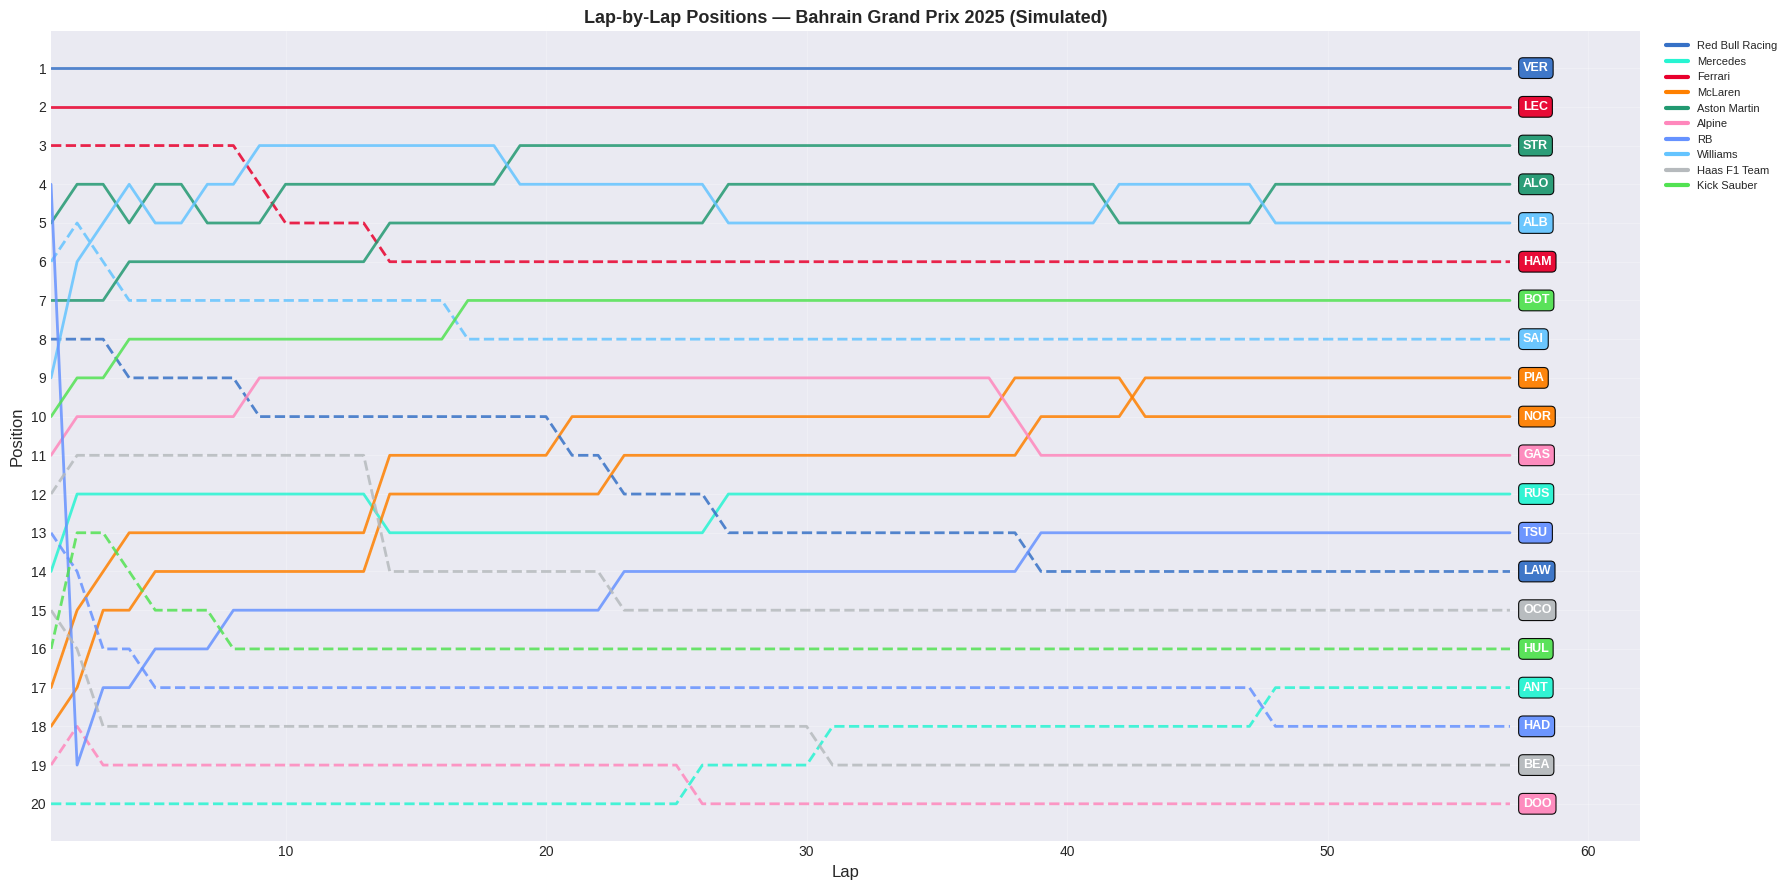

Gráfico guardado: Bahrain_Grand_Prix_positions_2025.png


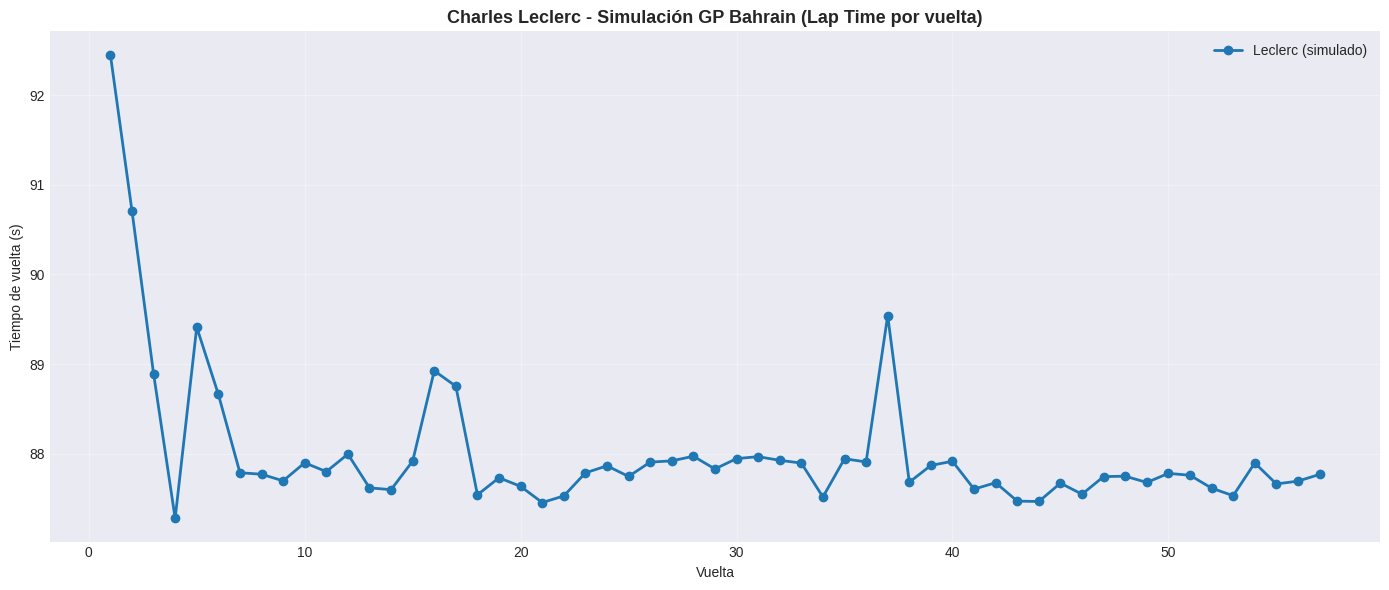

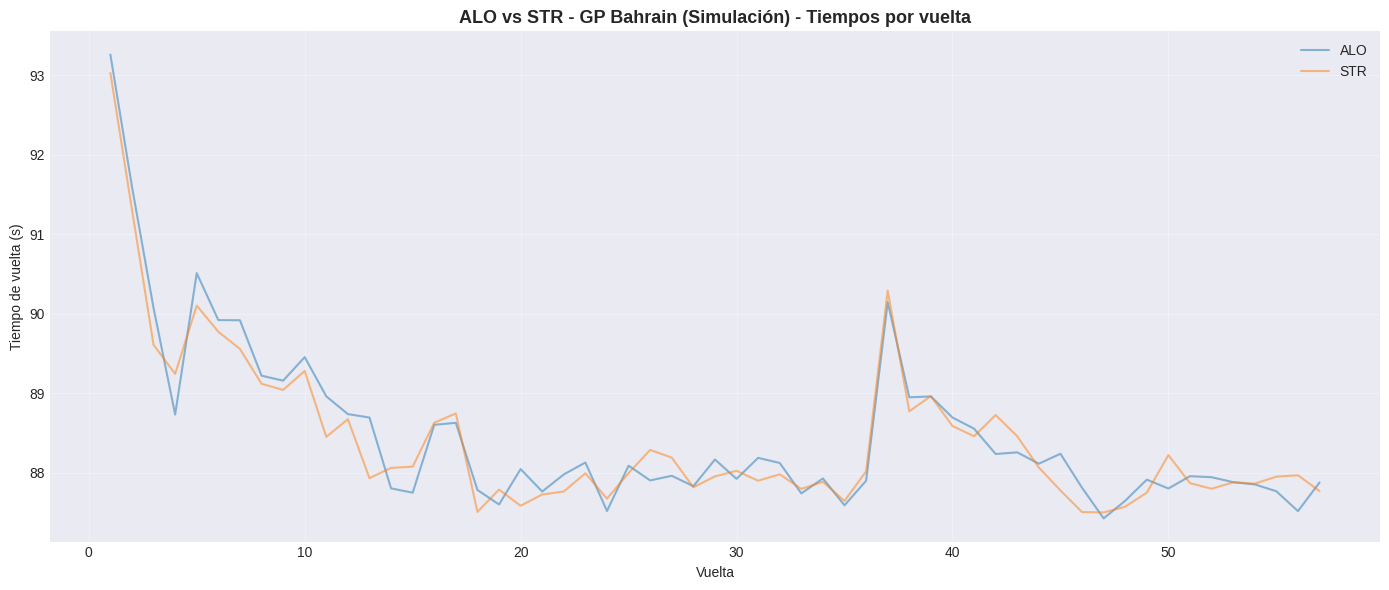

In [ ]:
# ─────────────────────────────────────────────
# EJECUTAR SIMULACIÓN — BAHRÉIN
# ─────────────────────────────────────────────

GP_NAME = 'Bahrain Grand Prix'
N_LAPS  = 57

print(f"\n{'='*50}")
print(f"  SIMULANDO: {GP_NAME} ({N_LAPS} vueltas)")
print(f"{'='*50}")

history_pos, sim_laptimes, resultado_final = simular_gp(
    gp_name        = GP_NAME,
    n_laps         = N_LAPS,
    driver_team    = driver_team_2025,
    race_number_map= {d: 1 for d in driver_team_2025},  # primera carrera del año
    noise_std      = 0.15
)

print(f"\n=== RESULTADO FINAL — {GP_NAME} 2025 (Simulado) ===")
print(resultado_final[['Position', 'Driver', 'Team']].to_string(index=False))

plot_gp_positions(history_pos, N_LAPS, GP_NAME, driver_team_2025)

#GRAFICO COMPARATIVO VUELTAS LECLERC
import matplotlib.pyplot as plt

driver = "LEC"

lec_times = sim_laptimes[driver]

plt.figure(figsize=(14,6))

plt.plot(
    range(1, len(lec_times) + 1),
    lec_times,
    marker="o",
    linewidth=2,
    label="Leclerc (simulado)"
)

plt.title("Charles Leclerc - Simulación GP Bahrain (Lap Time por vuelta)", fontsize=13, fontweight="bold")
plt.xlabel("Vuelta")
plt.ylabel("Tiempo de vuelta (s)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig('grafico_vueltas_leclerc_bahrein', dpi=150, bbox_inches='tight')
plt.show()


#GRAFICO COMPARATIVO LECLERC  VS HAMILTON

drivers = ["ALO", "STR"]

plt.figure(figsize=(14,6))

for d in drivers:
    if d in sim_laptimes and len(sim_laptimes[d]) > 0:

        laps = sim_laptimes[d]



        plt.plot(
            range(1, len(laps) + 1),
            laps,
            linewidth=1.5,
            alpha=0.5,
            label=f"{d}"
        )



plt.title("ALO vs STR - GP Bahrain (Simulación) - Tiempos por vuelta",  fontsize=13, fontweight="bold")
plt.xlabel("Vuelta")
plt.ylabel("Tiempo de vuelta (s)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('grafico_vueltas_alonso_vs_stroll_bahrein', dpi=150, bbox_inches='tight')
plt.show()